### Simulação de Efeitos de Tratamento heterogêneos

In [20]:
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from pyfixest.estimation import feols
import pyfixest as pf
from pyfixest.report.utils import rename_event_study_coefs

# CS ML
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

### Montando a simulação

A variável de interesse $ Y_{it} $ é gerada a partir da seguinte equação estrutural, incorporando efeitos fixos, variáveis observáveis, tratamento direto e spillover espacial:

$$
Y_{it} = \alpha + \lambda_t + \alpha_i + \beta \cdot \text{TE}_{it} + \gamma \cdot \text{Spill}_{it} + \delta_1 X_{1it} + \delta_2 X_{2it} + \delta_3 X_{3it} + \varepsilon_{it}
$$

Onde:

- $ \alpha $: intercepto constante
- $ \lambda_t = 0{,}01 \cdot (t - 2000) $: efeito fixo de tempo
- $ \alpha_i = 0{,}02 \cdot \text{cod}(i) $: efeito fixo de município
- $ \text{TE}_{it} = \min(\text{anos desde tratamento}, 3) $: efeito dinâmico truncado
- $ \text{Spill}_{it} = (W D_t)_i \cdot X\_index_{it} $: spillover espacial
- $ X_{1it}, X_{2it}, X_{3it} $: covariáveis observadas
- $ \varepsilon_{it} \sim \mathcal{N}(0, 0{,}3^2) $: erro idiossincrático

Com os coeficientes:

- $ \beta = 1{,}5 $: efeito direto do tratamento
- $ \gamma = 0{,}8 $: efeito spillover
- $ \delta_1 = 0{,}6,\ \delta_2 = 0{,}4,\ \delta_3 = 0{,}2 $

### Seleção para o Tratamento

O tratamento é atribuído com base em um escore de propensão logístico:

$$
\text{Pr}(D_i = 1) = \frac{1}{1 + \exp\left( -(\theta_1 X_{1i} + \theta_2 X_{2i} + \theta_3 X_{3i}) \right)}
$$

Com:

- $ \theta_1 = 1{,}5 $, $ \theta_2 = 1{,}0 $, $ \theta_3 = 0{,}5 $

Atribuição:

- 7% dos municípios com maior escore recebem o tratamento diretamente.
- 3% adicionais são selecionados aleatoriamente entre os demais.


In [4]:
# === Etapa 1: Carregar shapefile dos municípios do Brasil ===
shapefile_path = "C:/Users/danie/OneDrive/Data/Shape_BR_2022/BR_Municipios_2024.shp"
gdf = gpd.read_file(shapefile_path)

# Selecionar e renomear colunas principais
gdf = gdf[['CD_MUN', 'NM_MUN', 'SIGLA_UF', 'geometry']].copy()
gdf = gdf.rename(columns={'CD_MUN': 'codmun', 'NM_MUN': 'municipio', 'SIGLA_UF': 'uf'})

# Calcular centroides
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

# Mapeamento de UFs para regiões
regiao_dict = {
    'AC': 'Norte', 'AP': 'Norte', 'AM': 'Norte', 'PA': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'AL': 'Nordeste', 'BA': 'Nordeste', 'CE': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste',
    'PE': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste',
    'ES': 'Sudeste', 'MG': 'Sudeste', 'RJ': 'Sudeste', 'SP': 'Sudeste',
    'PR': 'Sul', 'RS': 'Sul', 'SC': 'Sul'
}

# Adiciona a coluna de região
gdf['regiao'] = gdf['uf'].map(regiao_dict)


# === Etapa 2: Simular covariáveis iniciais e suas tendências ===
np.random.seed(42)
n_mun = gdf.shape[0]
gdf['X1'] = np.random.normal(0, 1, n_mun)
gdf['X2'] = np.random.normal(0, 1, n_mun)
gdf['X3'] = np.random.normal(0, 1, n_mun)

# Aumentar os valores das variáveis X em 20% para Sul e Sudeste
regioes_ricas = ['Sul', 'Sudeste']
mask_ricas = gdf['regiao'].isin(regioes_ricas)
gdf.loc[mask_ricas, ['X1', 'X2', 'X3']] *= 1.2

# Tendência de crescimento heterogênea
gdf['X1_trend'] = np.random.normal(0.01, 0.005, n_mun)
gdf['X2_trend'] = np.random.normal(0.02, 0.007, n_mun)
gdf['X3_trend'] = np.random.normal(0.015, 0.004, n_mun)


# === Etapa 3: Expandir painel 2000–2024 com evolução dos X ===
years = list(range(2000, 2025))
panel = pd.DataFrame(
    [(row.codmun, row.municipio, row.uf,
      row.X1 + (year - 2000) * row.X1_trend,
      row.X2 + (year - 2000) * row.X2_trend,
      row.X3 + (year - 2000) * row.X3_trend,
      row.lat, row.lon, year)
     for idx, row in gdf.iterrows() for year in years],
    columns=['codmun', 'municipio', 'uf', 'X1', 'X2', 'X3', 'lat', 'lon', 'year']
)


# === Etapa 4: Atribuir tratamento a 10% dos municípios (7% via características, 3% aleatório) ===
np.random.seed(42)

# Passo 1: calcular escore de propensão ao tratamento
gdf['prop_score'] = 1 / (1 + np.exp(-(1.5 * gdf['X1'] + 1.0 * gdf['X2'] + 0.5 * gdf['X3'])))

# Passo 2: ordenar por escore e selecionar top 7%
n_7 = int(0.07 * n_mun)
treated_by_score = gdf.sort_values(by='prop_score', ascending=False).head(n_7)['codmun'].tolist()

# Passo 3: selecionar 3% aleatoriamente entre os restantes
remaining = gdf[~gdf['codmun'].isin(treated_by_score)]
n_3 = int(0.03 * n_mun)
treated_random = np.random.choice(remaining['codmun'], size=n_3, replace=False).tolist()

# Passo 4: juntar tratados
treated_muns = treated_by_score + treated_random
gdf['treated'] = gdf['codmun'].isin(treated_muns).astype(int)

# Passo 5: definir anos de tratamento entre 2005 e 2020
treatment_years = {mun: np.random.randint(2005, 2021) for mun in treated_muns}
panel['treat_year'] = panel['codmun'].map(treatment_years)
panel['D'] = ((panel['treat_year'].notnull()) & (panel['year'] >= panel['treat_year'])).astype(int)

# Calcular anos desde tratamento (efeito dinâmico)
panel['years_treated'] = (panel['year'] - panel['treat_year']).clip(lower=0)
panel['years_treated'] = panel['years_treated'].where(panel['D'] == 1, 0)
panel['treatment_effect'] = panel['years_treated'].clip(upper=3)


# === Etapa 5: Matriz de vizinhança espacial ===
w = Queen.from_dataframe(gdf)
W_sparse = w.full()[0]

# === Etapa 6: Recalcular índice socioeconômico por ano (com interações complexas) ===
panel['X_index'] = 0.0
for year in years:
    df_year = panel.loc[panel['year'] == year, ['X1', 'X2', 'X3']]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_year)
    X1s, X2s, X3s = X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2]
    
    X_index_new = (
        0.5 * (X1s + X2s + X3s) +
        0.3 * (X1s * X2s) +
        0.2 * (X1s**2 * X2s * X3s)
    )
    panel.loc[panel['year'] == year, 'X_index'] = X_index_new

# === Etapa 7: Calcular spillover espacial ===
panel['spillover'] = 0.0
for year in years:
    Dt = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(Dt['D']).fillna(0).values.reshape(-1, 1)
    spill_raw = W_sparse @ D_vector
    spill_strength = spill_raw.flatten() * panel.loc[panel['year'] == year, 'X_index'].values
    panel.loc[panel['year'] == year, 'spillover'] = spill_strength

# === Etapa 8: Gerar variável de resultado Y ===
np.random.seed(42)
panel['alpha_i'] = panel['codmun'].astype('category').cat.codes * 0.02
panel['lambda_t'] = (panel['year'] - 2000) * 0.01
panel['epsilon'] = np.random.normal(0, 0.3, panel.shape[0])

# Coeficientes de impacto
beta = 1.5  # efeito direto
gamma = 0.8  # efeito spillover

panel['Y'] = (
    2 +
    0.6 * panel['X1'] +
    0.4 * panel['X2'] +
    0.2 * panel['X3'] +
    beta * panel['treatment_effect'] +
    gamma * panel['spillover'] +
    panel['alpha_i'] +
    panel['lambda_t'] +
    panel['epsilon']
)

Visualizando o mapa do Brasil com os municípios que foram tratados e não tratados.

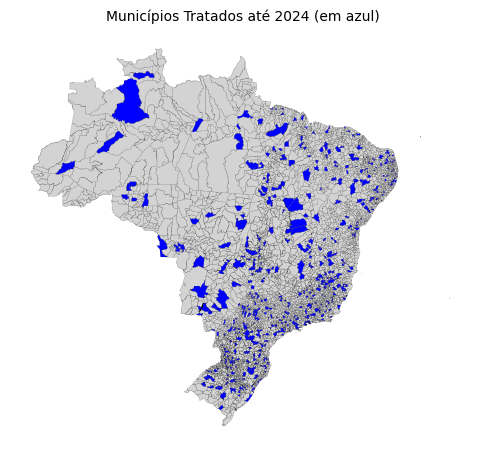

In [5]:
# Filtra apenas o último ano (2024)
panel_2024 = panel[panel['year'] == 2024]

# Junta com o GeoDataFrame para obter as geometrias
mapa_2024 = gdf.merge(panel_2024[['codmun', 'D']], on='codmun', how='left')

# Plota o mapa: municípios tratados (D=1) em azul, os demais em cinza claro
fig, ax = plt.subplots(figsize=(6, 7))
mapa_2024[mapa_2024['D'] == 0].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
mapa_2024[mapa_2024['D'] == 1].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados até 2024 (em azul)', fontsize=10)
ax.axis('off')
plt.show()

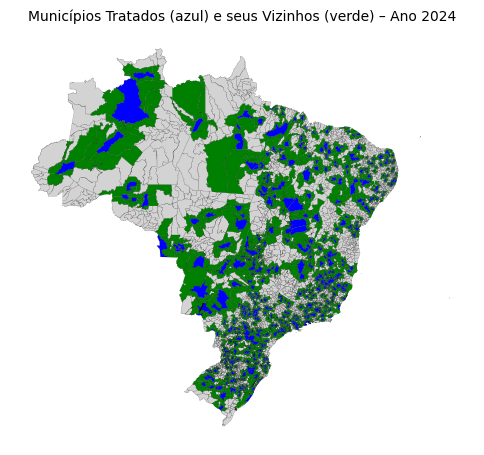

In [6]:
# 1. Filtra ano de 2024
panel_2024 = panel[panel['year'] == 2024]

# 2. Municípios tratados até 2024
treated_muns = set(panel_2024.loc[panel_2024['D'] == 1, 'codmun'])

# 3. Identifica vizinhos dos tratados
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# Coleta todos os vizinhos dos tratados
vizinhos = set()
for mun in treated_muns:
    idx = codmun_to_index.get(mun)
    if idx is not None:
        vizinhos.update([index_to_codmun[i] for i in neighbors_dict.get(idx, [])])

# Remove os próprios tratados da lista de vizinhos
vizinhos = vizinhos - treated_muns

# 4. Classificação para visualização
gdf['status'] = 'Não tratado'
gdf.loc[gdf['codmun'].isin(vizinhos), 'status'] = 'Vizinho tratado'
gdf.loc[gdf['codmun'].isin(treated_muns), 'status'] = 'Tratado'

# 5. Mapa com 3 cores
fig, ax = plt.subplots(figsize=(6, 7))
gdf[gdf['status'] == 'Não tratado'].plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Vizinho tratado'].plot(ax=ax, color='green', edgecolor='black', linewidth=0.08)
gdf[gdf['status'] == 'Tratado'].plot(ax=ax, color='blue', edgecolor='black', linewidth=0.08)

# Estilização
ax.set_title('Municípios Tratados (azul) e seus Vizinhos (verde) – Ano 2024', fontsize=10)
ax.axis('off')
plt.show()


Filtragem adicional da base

* vizinho de tratado
* ano que esse vizinho foi "tratado"
* grupo de tratados
* grupo de vizinhos tratados
* nunca tratados


Adiciona o uma variável de efeito espacial do tratamento (1 para os vizinhos dos municípios tratados, 0 caso contrário).

In [7]:
# Inicializa a coluna WD no panel
panel['WD'] = 0.0

# Calcula WD ano a ano (importante manter a ordem correta dos municípios)
for year in years:
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # respeita a ordem do gdf
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()

In [8]:
# 1. Obter os municípios tratados (independente do ano)
treated_codmuns = gdf[gdf['treated'] == 1]['codmun'].tolist()

# 2. Construir o dicionário de vizinhos (índice → codmun)
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}

# 3. Coletar todos os vizinhos dos tratados
vizinhos_tratados = set()
for mun in treated_codmuns:
    idx = codmun_to_index.get(mun)
    vizinhos_idx = neighbors_dict.get(idx, [])
    vizinhos_cod = [index_to_codmun[i] for i in vizinhos_idx]
    vizinhos_tratados.update(vizinhos_cod)

# 4. Remover os próprios tratados (só queremos vizinhos puros)
vizinhos_tratados -= set(treated_codmuns)

# 5. Criar a variável indicadora no painel
panel['is_neighbor_of_treated'] = panel['codmun'].isin(vizinhos_tratados).astype(int)

In [9]:
# 1. Dicionário com o ano de tratamento de cada município
treat_year_dict = panel[['codmun', 'treat_year']].dropna().drop_duplicates().set_index('codmun')['treat_year'].to_dict()

# 2. Dicionário de vizinhos: codmun → lista de codmuns vizinhos
neighbors_dict = w.neighbors
index_to_codmun = dict(zip(gdf.index, gdf['codmun']))
codmun_to_index = {v: k for k, v in index_to_codmun.items()}
codmun_neighbors = {
    codmun: [index_to_codmun[i] for i in neighbors_dict.get(codmun_to_index[codmun], [])]
    for codmun in gdf['codmun']
}

# 3. Função para obter o menor ano de tratamento entre os vizinhos
def get_earliest_neighbor_treat_year(codmun, year):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict and treat_year_dict[v] <= year]
    return min(anos_tratamento) if anos_tratamento else None

# 4. Criar a nova variável no panel
panel['g_neighbor_of_treated_a'] = panel.apply(
    lambda row: get_earliest_neighbor_treat_year(row['codmun'], row['year']),
    axis=1
)

In [10]:
# Versão ESTÁTICA: menor ano de tratamento dos vizinhos, mesmo que ainda não tenha ocorrido
def get_min_neighbor_treat_year(codmun):
    vizinhos = codmun_neighbors.get(codmun, [])
    anos_tratamento = [treat_year_dict[v] for v in vizinhos if v in treat_year_dict]
    return min(anos_tratamento) if anos_tratamento else None

# Criar coluna fixa no gdf
gdf['g_neighbor_of_treated'] = gdf['codmun'].apply(get_min_neighbor_treat_year)

# Juntar com panel
panel = panel.merge(gdf[['codmun', 'g_neighbor_of_treated']], on='codmun', how='left')

In [11]:
# Criar coluna 'treated' para indicar se o município foi tratado (1) ou não (0), se treat_year > 0
panel['treated'] = (panel['treat_year'] > 0).astype(int)
# Criar coluna 'neighbor_of_treated' para indicar se o município foi tratado (1) ou não (0), se g_neighbor_of_treated > 0
panel['neighbor_of_treated'] = (panel['g_neighbor_of_treated'] > 0).astype(int)
# nunca tratados: aqueles que não foram tratados nem são vizinhos de tratados
panel['never_treated'] = ((panel['treated'] == 0) & (panel['neighbor_of_treated'] == 0)).astype(int)

In [12]:
panel['g_treated'] = panel['treat_year'].where(panel['treated'] == 1, np.nan)
panel['g_neighbor'] = panel['g_neighbor_of_treated'].where(panel['neighbor_of_treated'] == 1, np.nan)

In [13]:
# treated e never treated panel (efeitos diretos)
panel_de = panel[(panel['treated'] == 1) | (panel['never_treated'] == 1)].copy()
# neighbor of treated e never treated panel (efeitos indiretos, excluindo tratados diretos)
panel_id = panel[((panel['neighbor_of_treated'] == 1) & (panel['treated'] == 0)) | (panel['never_treated'] == 1)].copy()

### Verificando modelos em busca do efeito do tratamento

In [14]:
# Regressão linear simples: Y ~ D
df_reg = panel.copy()

X = sm.add_constant(df_reg['D'])  # adiciona intercepto
y = df_reg['Y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     640.3
Date:                Thu, 17 Jul 2025   Prob (F-statistic):          6.09e-141
Time:                        19:18:55   Log-Likelihood:            -6.8142e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139323   BIC:                         1.363e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.9252      0.088    655.063      0.0

In [15]:
X = sm.add_constant(df_reg[['D', 'X1', 'X2', 'X3']])  # adiciona intercepto
y = df_reg['Y']

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     183.2
Date:                Thu, 17 Jul 2025   Prob (F-statistic):          7.27e-157
Time:                        19:19:05   Log-Likelihood:            -6.8137e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139320   BIC:                         1.363e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         57.8466      0.091    637.342      0.0

#### TWFE

In [16]:
twfe_model = feols("Y ~ D | year + codmun", data=panel)
print(twfe_model.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.735 |        0.182 |    20.547 |      0.000 |  3.360 |   4.110 |
---
RMSE: 0.494 R2: 1.0 R2 Within: 0.535 
None


In [17]:
twfe_model2 = feols("Y ~ D + X1 + X2 + X3| year + codmun", data=panel)
print(twfe_model2.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.737 |        0.182 |    20.529 |      0.000 |  3.362 |   4.113 |
| X1            |      0.748 |        0.023 |    31.898 |      0.000 |  0.699 |   0.796 |
| X2            |      0.553 |        0.017 |    33.305 |      0.000 |  0.519 |   0.587 |
| X3            |      0.183 |        0.046 |     3.980 |      0.001 |  0.088 |   0.278 |
---
RMSE: 0.492 R2: 1.0 R2 Within: 0.537 
None


### Diferença em Diferença Espacial (Spatial DiD) conforme Delgado e Florax (2015)

O modelo clássico a ser estimado é:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \epsilon_{it} $$

Ou seja, precisamos:

- Y: resultado
- D: variável de tratamento
- WD: spillover espacial, que precisa ser calculado com base na vizinhança espacial (matriz W) e a variável D
- Efeitos fixos: município (codmun) e tempo (year)


In [18]:
# Converte para categoria para gerar dummies automaticamente
panel['codmun'] = panel['codmun'].astype('category')
panel['year'] = panel['year'].astype('category')

In [21]:
# Regressão com efeitos fixos + D + WD
model_DD_wd = smf.ols('Y ~ D + WD + C(codmun) + C(year)', data=panel)
results_DD_wd = model_DD_wd.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município
print(results_DD_wd.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.247e+17
Date:                Thu, 17 Jul 2025   Prob (F-statistic):               0.00
Time:                        19:35:20   Log-Likelihood:                -81072.
No. Observations:              139325   AIC:                         1.733e+05
Df Residuals:                  133726   BIC:                         2.285e+05
Df Model:                        5598                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.7240 

Adicionando covariáveis:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \delta X_{it} + \epsilon_{it} $$


In [22]:
# Regressão com efeitos fixos e covariáveis: + D + WD + X1 + X2 + X3
model2_DD_wd = smf.ols('Y ~ D + WD + C(codmun) + C(year) + X1 + X2 + X3', data=panel)
results2_DD_wd = model2_DD_wd.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município
print(results2_DD_wd.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                -2.852e+15
Date:                Thu, 17 Jul 2025   Prob (F-statistic):               1.00
Time:                        20:13:29   Log-Likelihood:                -80640.
No. Observations:              139325   AIC:                         1.725e+05
Df Residuals:                  133723   BIC:                         2.276e+05
Df Model:                        5601                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.8739 

#### Gardner (2022)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Gardner (2022).

O modelo de Gardner (2022) está estimando o efeito médio do tratamento sobre os tratados (ATT), de forma agregada ou média, controlando por efeitos fixos e covariáveis (se houver), mas corrigindo um problema comum nas abordagens tradicionais baseadas em dois estágios (two-way fixed effects - TWFE): viés de composição causado por comparação entre grupos tratados em momentos diferentes.

* Ele evita o viés de comparação entre grupos tratados em momentos diferentes, porque o segundo estágio utiliza apenas a variação do tratamento ao longo do tempo, após controlar para efeitos fixos e covariáveis.
* Ao não incluir diretamente os efeitos fixos na segunda regressão, ele evita problemas de colinearidade e viés de composição que afetam o modelo TWFE tradicional.

**Primeiro Estágio: Remoção de efeitos fixos e covariáveis**

Neste passo, estima-se uma regressão linear do desfecho sobre covariáveis e efeitos fixos de unidade e tempo:
 
$$
Y_{it} = X_{it}'\beta + \gamma_i + \delta_t + \epsilon_{it}
$$
 
Onde:  
- $\gamma_i$ representa o efeito fixo da unidade,  
- $\delta_t$ representa o efeito fixo de tempo,  
- $X_{it}$ são as covariáveis.
 
Após essa regressão, obtêm-se os **resíduos ajustados**:

$$
\tilde{Y}_{it} = Y_{it} - \hat{X}_{it}'\hat{\beta} - \hat{\gamma}_i - \hat{\delta}_t
$$
 
**Segundo Estágio: Estimação do efeito do tratamento**
 
Regressa-se o resíduo $\tilde{Y}_{it}$ apenas na variável de tratamento $D_{it}$ (por exemplo, uma dummy indicando o período pós-tratamento):

$$
\tilde{Y}_{it} = \theta \cdot D_{it} + u_{it}
$$

O coeficiente $\theta$ obtido dessa regressão representa a **estimativa do efeito médio do tratamento sobre os tratados (ATT)**.

In [29]:
# Converta treat_year para float antes de aplicar np.inf
panel['treat_year'] = pd.to_numeric(panel['treat_year'], errors='coerce').astype(float)

# Agora sim, preencha com np.inf
panel['treat_year'] = panel['treat_year'].fillna(np.inf)
panel['rel_year'] = panel['year'] - panel['treat_year']

In [30]:
# Estima o modelo de Gardner (did2s) com covariáveis
fit_gardner = pf.did2s(
    data=panel,
    yname="Y",                     # variável dependente
    treatment="D",                # dummy de tratamento
    first_stage="~ X1 + X2 + X3 | codmun + year",  # controles + efeitos fixos
    second_stage="~ D",           # variável de interesse
    cluster="codmun"              # erro padrão clusterizado
)
print(fit_gardner.summary())

MemoryError: Unable to allocate 5.81 GiB for an array with shape (139325, 5600) and data type float64

***Gardner - Event Study***

In [17]:
fit_did2s = pf.did2s(
    data=panel,
    yname="Y", 
    treatment="D",
    first_stage="~ 0 |  codmun + year",
    second_stage="~i(rel_year, ref= -1.0)",
    cluster="codmun",
)

In [21]:
figsize = [600, 400]

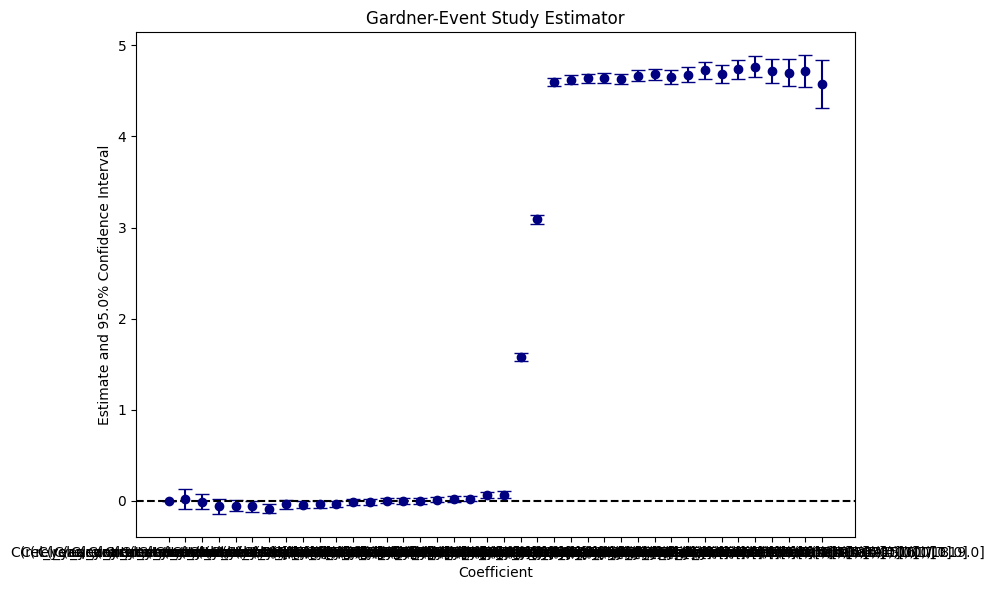

In [31]:
fit_did2s.iplot(coord_flip=False, title="Gardner-Event Study Estimator", yintercept=0)

In [28]:
fit_did2s_v2 = pf.did2s(
    data=panel,
    yname="Y", 
    treatment="D",
    first_stage="~ X1 + X2 + X3 | codmun + year",
    second_stage="~i(rel_year, ref= -1.0)",
    cluster="codmun",
)

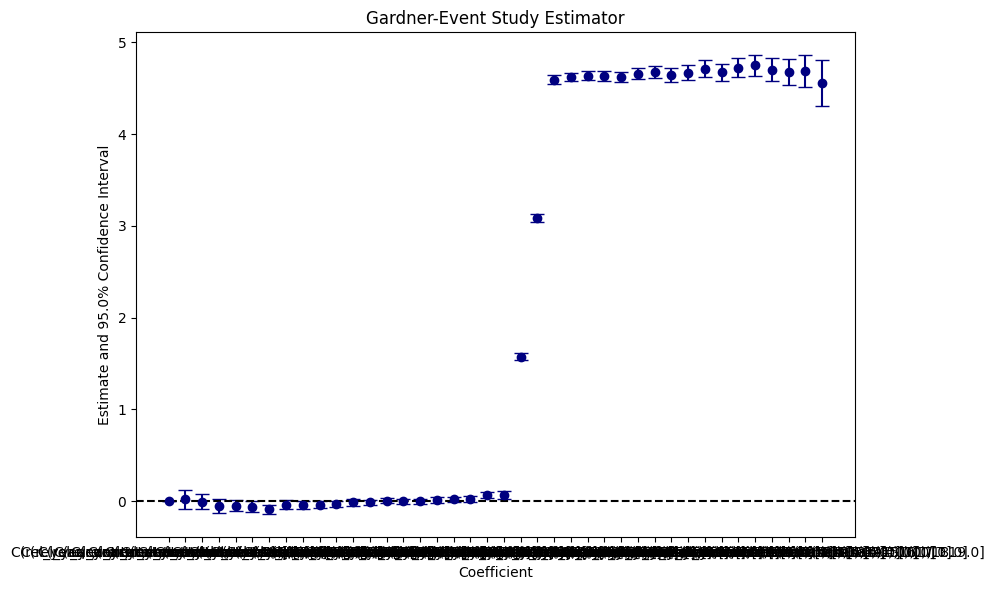

In [33]:
fit_did2s_v2.iplot(coord_flip=False, title="Gardner-Event Study Estimator", yintercept=0)

In [36]:
fit_did2s_v2.summary()

###

Estimation:  DID2S
Dep. var.: Y_hat, Fixed effects: 0
Inference:  CRV1 (GMM)
Observations:  139325

| Coefficient                                     |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:------------------------------------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| C(rel_year,contr.treatment(base=-1.0))[T.-inf]  |     -0.000 |        0.000 |   -70.824 |      0.000 | -0.000 |  -0.000 |
| C(rel_year,contr.treatment(base=-1.0))[T.-20.0] |      0.020 |        0.054 |     0.368 |      0.713 | -0.086 |   0.125 |
| C(rel_year,contr.treatment(base=-1.0))[T.-19.0] |     -0.007 |        0.041 |    -0.163 |      0.871 | -0.086 |   0.073 |
| C(rel_year,contr.treatment(base=-1.0))[T.-18.0] |     -0.055 |        0.041 |    -1.344 |      0.179 | -0.134 |   0.025 |
| C(rel_year,contr.treatment(base=-1.0))[T.-17.0] |     -0.052 |        0.031 |    -1.657 |      0.098 | -0.113 |   0.009 |
| C(rel_year,contr.treatmen

### Sun & Abraham (2020)

O modelo de Sun & Abraham (2020) é uma extensão do modelo TWFE, que busca corrigir o viés de composição causado por diferenças temporais no tratamento entre grupos tratados. Ele utiliza uma abordagem de regressão em dois estágios, semelhante ao modelo de Gardner (2022), mas com foco na heterogeneidade do tratamento.




In [95]:
fit_sun_abraham = pf.event_study(
    data=panel,
    yname="Y",
    idname="codmun",
    tname="year",
    gname="treat_year",     # coluna que indica o ano de tratamento de cada unidade
    estimator="saturated",  # Modelo de Sun & Abraham
    cluster="codmun",
    att=True
)

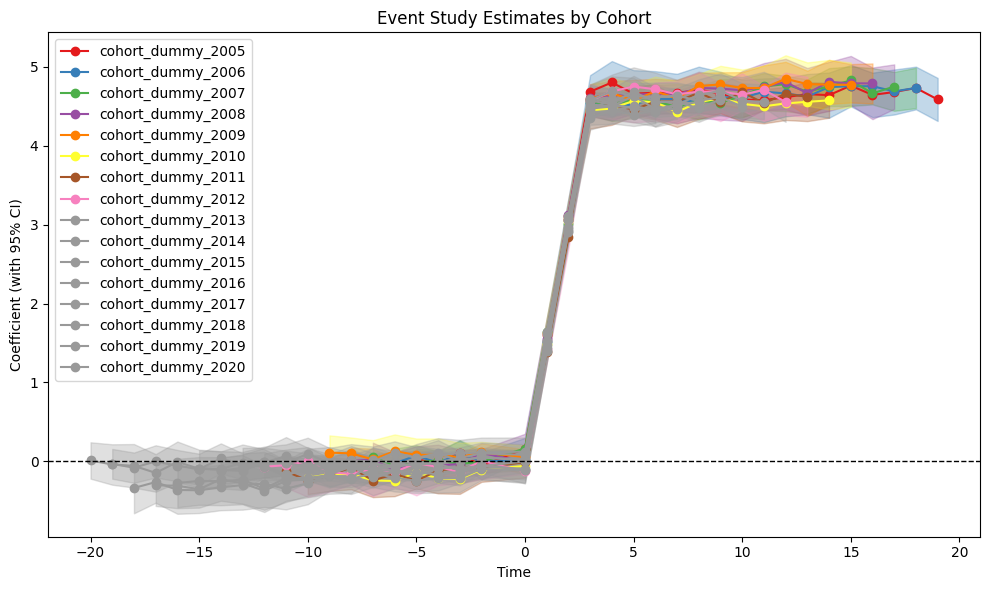

In [45]:
fit_sun_abraham.iplot()

In [98]:
print(fit_sun_abraham.tidy())


                                                    Estimate  Std. Error  \
Coefficient                                                                
C(rel_time,contr.treatment(base=-1.0))[T.-5.0]:...  0.031137    0.067720   
C(rel_time,contr.treatment(base=-1.0))[T.-4.0]:... -0.041495    0.090961   
C(rel_time,contr.treatment(base=-1.0))[T.-3.0]:...  0.110385    0.076695   
C(rel_time,contr.treatment(base=-1.0))[T.-2.0]:... -0.061312    0.086854   
C(rel_time,contr.treatment(base=-1.0))[T.0.0]:c...  0.161114    0.069004   
...                                                      ...         ...   
C(rel_time,contr.treatment(base=-1.0))[T.0.0]:c...  0.003078    0.063285   
C(rel_time,contr.treatment(base=-1.0))[T.1.0]:c...  1.521608    0.063334   
C(rel_time,contr.treatment(base=-1.0))[T.2.0]:c...  3.099154    0.060470   
C(rel_time,contr.treatment(base=-1.0))[T.3.0]:c...  4.452022    0.049389   
C(rel_time,contr.treatment(base=-1.0))[T.4.0]:c...  4.593821    0.063965   

           

In [93]:
print(fit_sun_abraham.tidy().head(10))

                                                    Estimate  Std. Error  \
Coefficient                                                                
C(rel_time,contr.treatment(base=-1.0))[T.-5.0]:...  0.031137    0.067720   
C(rel_time,contr.treatment(base=-1.0))[T.-4.0]:... -0.041495    0.090961   
C(rel_time,contr.treatment(base=-1.0))[T.-3.0]:...  0.110385    0.076695   
C(rel_time,contr.treatment(base=-1.0))[T.-2.0]:... -0.061312    0.086854   
C(rel_time,contr.treatment(base=-1.0))[T.0.0]:c...  0.161114    0.069004   
C(rel_time,contr.treatment(base=-1.0))[T.1.0]:c...  1.604870    0.090619   
C(rel_time,contr.treatment(base=-1.0))[T.2.0]:c...  3.111670    0.110461   
C(rel_time,contr.treatment(base=-1.0))[T.3.0]:c...  4.685785    0.107185   
C(rel_time,contr.treatment(base=-1.0))[T.4.0]:c...  4.802838    0.138402   
C(rel_time,contr.treatment(base=-1.0))[T.5.0]:c...  4.661240    0.151899   

                                                      t value  Pr(>|t|)  \
Coefficient 

In [85]:
fit_sun_abraham_covs = pf.event_study(
    data=panel,
    yname="Y",
    idname="codmun",
    tname="year",
    gname="treat_year",
    xfml="X1 + X2 + X3",
    estimator="saturated",
    cluster="codmun",
    att=True  # <- isso força o uso dos grupos tratados apenas
)


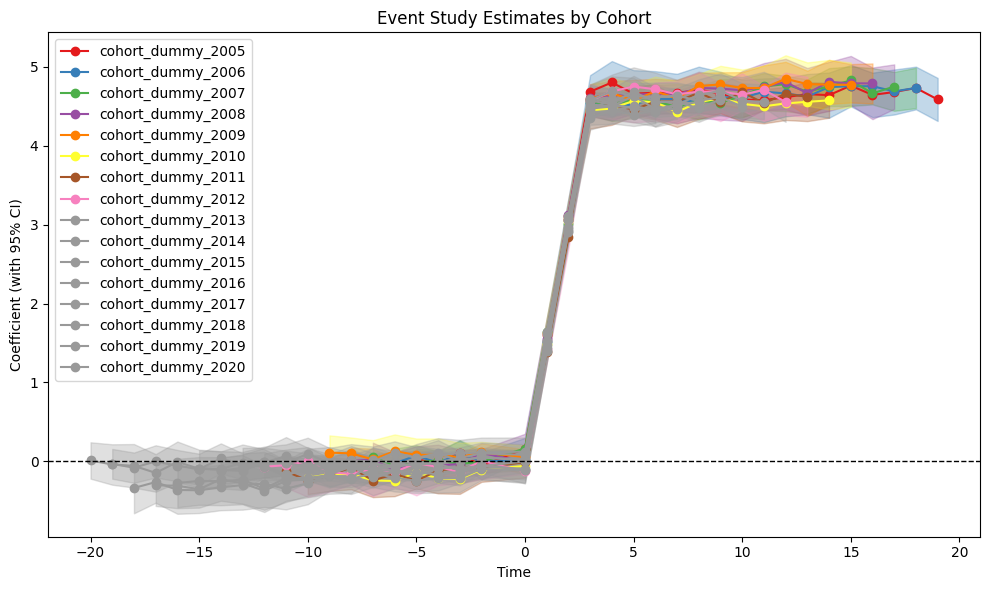

In [86]:
fit_sun_abraham_covs.iplot()

In [ ]:
print(fit_sun_abraham_covs.tidy().head(10))


                                                    Estimate  Std. Error  \
Coefficient                                                                
C(rel_time,contr.treatment(base=-1.0))[T.-5.0]:...  0.031137    0.067720   
C(rel_time,contr.treatment(base=-1.0))[T.-4.0]:... -0.041495    0.090961   
C(rel_time,contr.treatment(base=-1.0))[T.-3.0]:...  0.110385    0.076695   
C(rel_time,contr.treatment(base=-1.0))[T.-2.0]:... -0.061312    0.086854   
C(rel_time,contr.treatment(base=-1.0))[T.0.0]:c...  0.161114    0.069004   
C(rel_time,contr.treatment(base=-1.0))[T.1.0]:c...  1.604870    0.090619   
C(rel_time,contr.treatment(base=-1.0))[T.2.0]:c...  3.111670    0.110461   
C(rel_time,contr.treatment(base=-1.0))[T.3.0]:c...  4.685785    0.107185   
C(rel_time,contr.treatment(base=-1.0))[T.4.0]:c...  4.802838    0.138402   
C(rel_time,contr.treatment(base=-1.0))[T.5.0]:c...  4.661240    0.151899   

                                                      t value  Pr(>|t|)  \
Coefficient 

#### Callaway & Sant'Anna (2021)

Vamos estimar o efeito do tratamento considerando a heterogeneidade do tratamento, conforme o modelo de Callaway e Sant'Anna (2021). Desconsiderando o efeito espacial.


Precisamos ajustar a base para que o estimador funcione corretamente.

In [180]:
panel.loc[panel['g_treated'] == 0, 'g_treated'] = np.inf
panel['g_treated'] = panel['g_treated'].astype(float)
panel['year'] = panel['year'].astype(int)
panel['g_treated'] = panel['g_treated'].fillna(np.inf)
panel = panel.sort_values(by=['codmun', 'year']).reset_index(drop=True)

Identificando a base de dados para utilizar com o modelo de ML.

In [181]:
dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['g_treated']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139325 entries, 0 to 139324
Columns: 28 entries, codmun to g_neighbor
dtypes: category(1), float64(19), int64(6), object(2)
memory usage: 29.1+ MB



Rodando o modelo.

In [182]:
dml_obj = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)
dml_obj.fit()
print(dml_obj.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001) -0.0728   0.0732  -0.9936  0.3204 -0.2163  0.0708
ATT(2005.0,2001,2002)  0.1519   0.0786   1.9319  0.0534 -0.0022  0.3061
ATT(2005.0,2002,2003) -0.1718   0.0758  -2.2660  0.0234 -0.3205 -0.0232
ATT(2005.0,2003,2004)  0.0613   0.0867   0.7074  0.4793 -0.1085  0.2312
ATT(2005.0,2004,2005)  0.1613   0.0688   2.3450  0.0190  0.0265  0.2961
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.0031   0.0632   0.0483  0.9614 -0.1209  0.1270
ATT(2020.0,2019,2021)  1.5216   0.0632  24.0566  0.0000  1.3976  1.6455
ATT(2020.0,2019,2022)  3.0991   0.0603  51.3748  0.0000  2.9809  3.2174
ATT(2020.0,2019,2023)  4.4520   0.0494  90.0613  0.0000  4.3551  4.5489
ATT(2020.0,2019,2024)  4.5938   0.0639  71.9462  0.0000  4.4687  4.7190

[384 rows x 6 columns]


Criando os ICs.

In [183]:
level = 0.95
ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.348666  0.203139
ATT(2005.0,2001,2002) -0.144368  0.448253
ATT(2005.0,2002,2003) -0.457519  0.113854
ATT(2005.0,2003,2004) -0.265188  0.387803
ATT(2005.0,2004,2005) -0.097849  0.420467
...                         ...       ...
ATT(2020.0,2019,2020) -0.235145  0.241258
ATT(2020.0,2019,2021)  1.283269  1.759854
ATT(2020.0,2019,2022)  2.871877  3.326421
ATT(2020.0,2019,2023)  4.265749  4.638226
ATT(2020.0,2019,2024)  4.353269  4.834386

[384 rows x 2 columns]


Plotando os resultados.

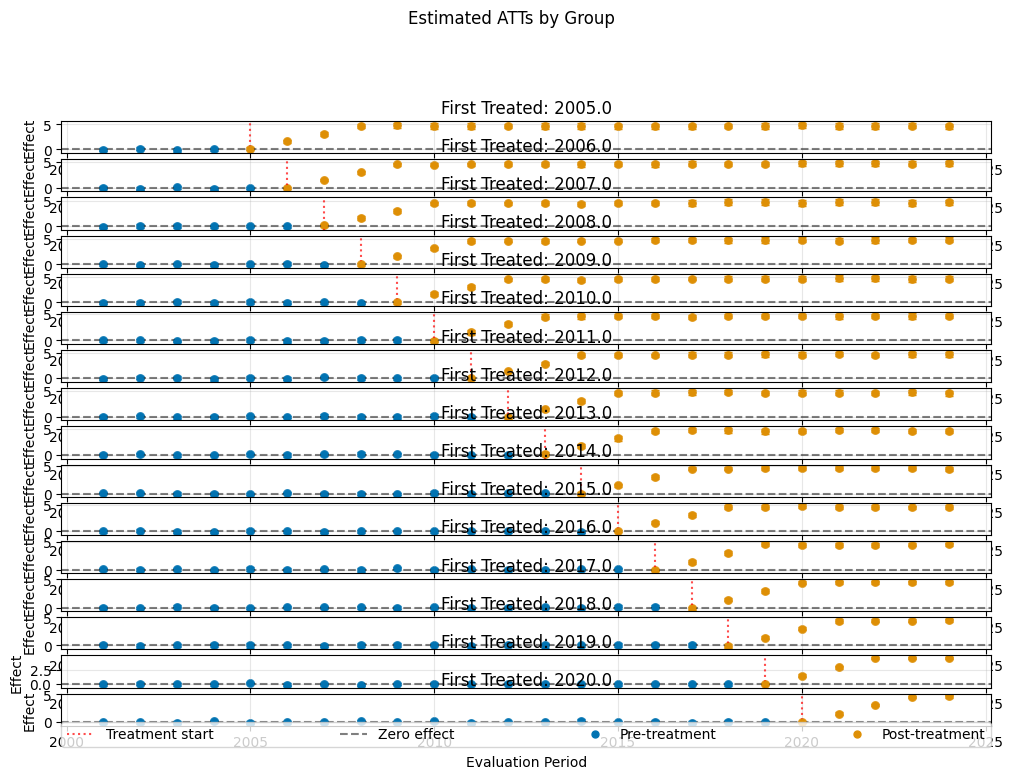

In [184]:
fig, ax = dml_obj.plot_effects()

Event Study

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.172163 0.031598 132.039201    0.0 4.110232 4.234094
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.051015  0.070757   -0.720995  0.470913 -0.189696  0.087665
-18.0 -0.033001  0.050233   -0.656966  0.511203 -0.131456  0.065453
-17.0  0.015182  0.039443    0.384922  0.700295 -0.062124  0.092489
-16.0  0.003422  0.032897    0.104023  0.917151 -0.061056  0.067900
-15.0 -0.034925  0.028086   -1.243494  0.213686 -0.089973  0.020123
-14.0  0.049557  0.028551    1.735700  0.082617 -0.006403  0.105516
-13.0 -0.003855  0.026902   -0.143311  0.886045 -0.056582  0.048871
-12.0 -0.001766  0.022435   -0.078737  0.937242 -0.045737  0.042204
-11.0  0.002722  0.023779    0.114457  0.908876 -0.0438

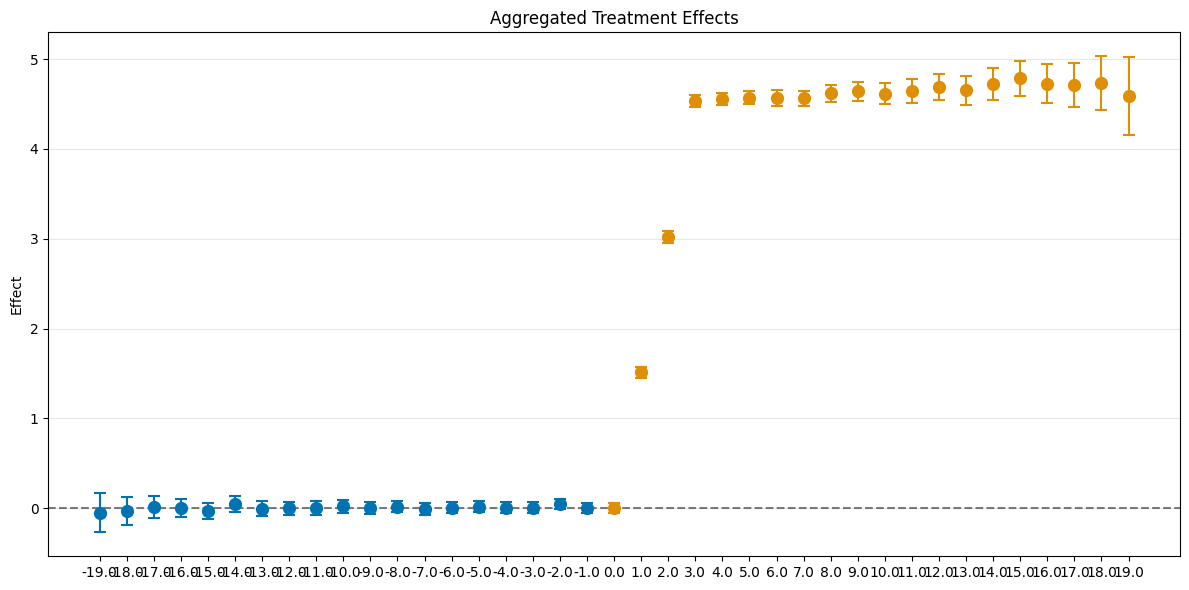

In [185]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj.bootstrap(n_rep_boot=5000)
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy)
fig, ax = aggregated_eventstudy.plot_effects()

Modelo com:
* mg(.): regressão linear
* ml(.): regressão logistica

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

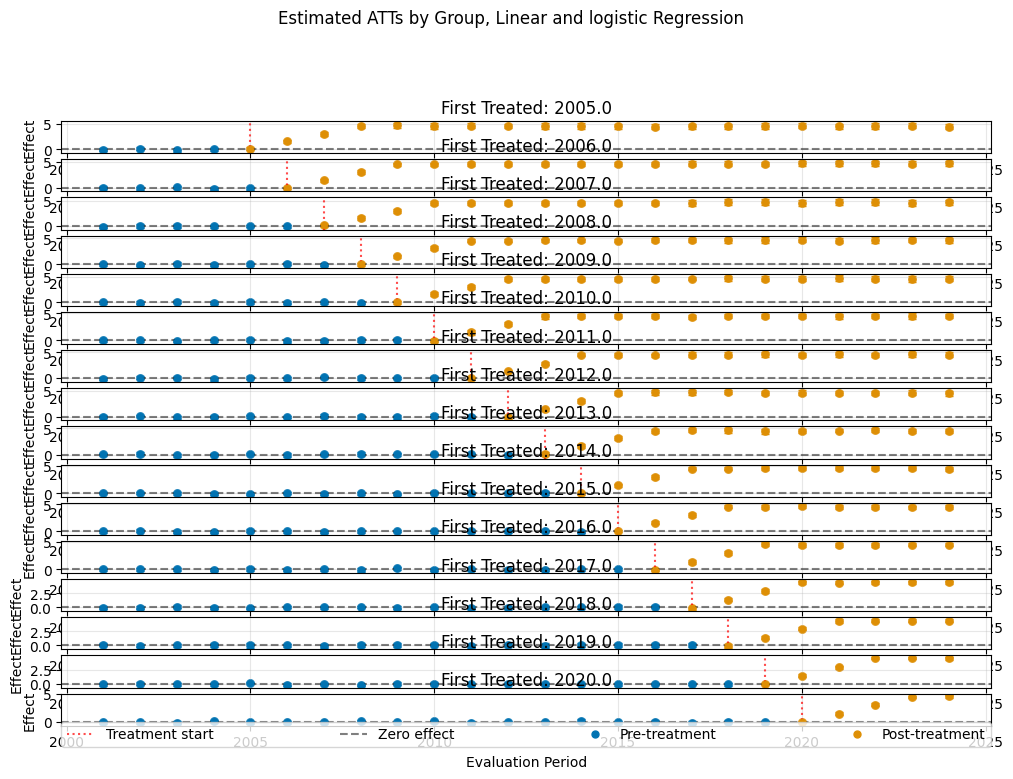

In [186]:
dml_obj_linear_logistic = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_linear_logistic.fit()
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
dml_obj_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, Linear and logistic Regression'}, ylabel='Effect'>)

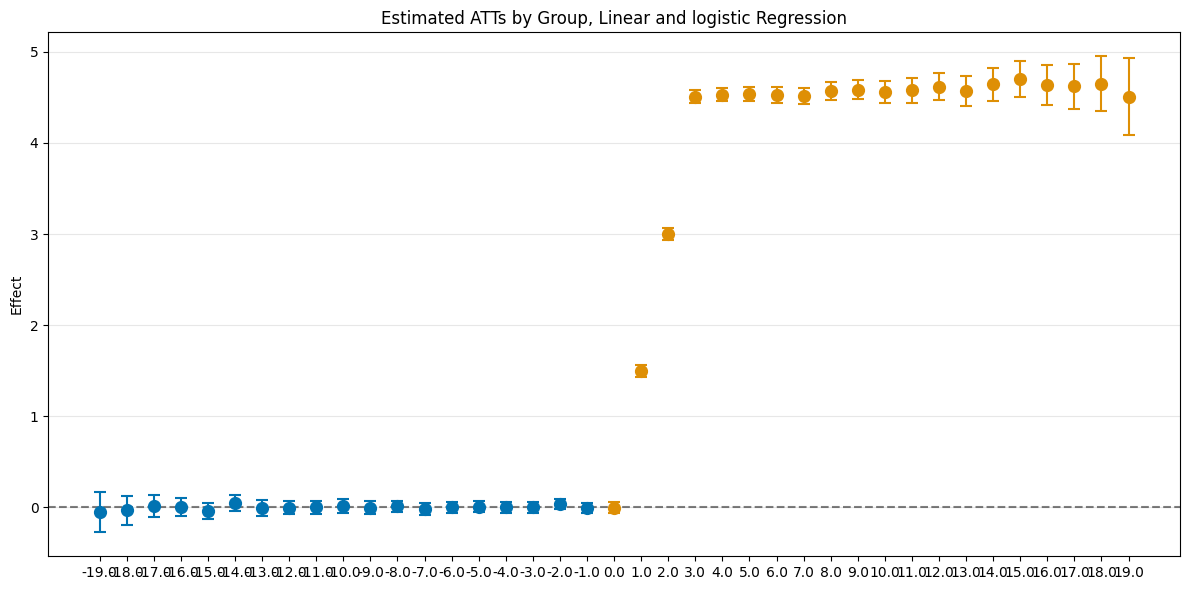

In [187]:
es_linear_logistic = dml_obj_linear_logistic.aggregate("eventstudy")
es_linear_logistic.aggregated_frameworks.bootstrap()
es_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.116989 0.031632 130.154164    0.0 4.054992 4.178985
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.051050  0.071041   -0.718592  0.472392 -0.190287  0.088188
-18.0 -0.030754  0.050292   -0.611505  0.540865 -0.129326  0.067817
-17.0  0.018799  0.039370    0.477498  0.633007 -0.058365  0.095963
-16.0  0.004899  0.033014    0.148381  0.882042 -0.059808  0.069605
-15.0 -0.034465  0.028139   -1.224837  0.220637 -0.089616  0.020685
-14.0  0.049471  0.028591    1.730312  0.083575 -0.006566  0.105508
-13.0 -0.005831  0.026962   -0.216260  0.828785 -0.058676  0.047014
-12.0 -0.004330  0.022434   -0.193016  0.846947 -0.048301  0.039640
-11.0  0.000527  0.023825    0.022138  0.982338 -0.0461

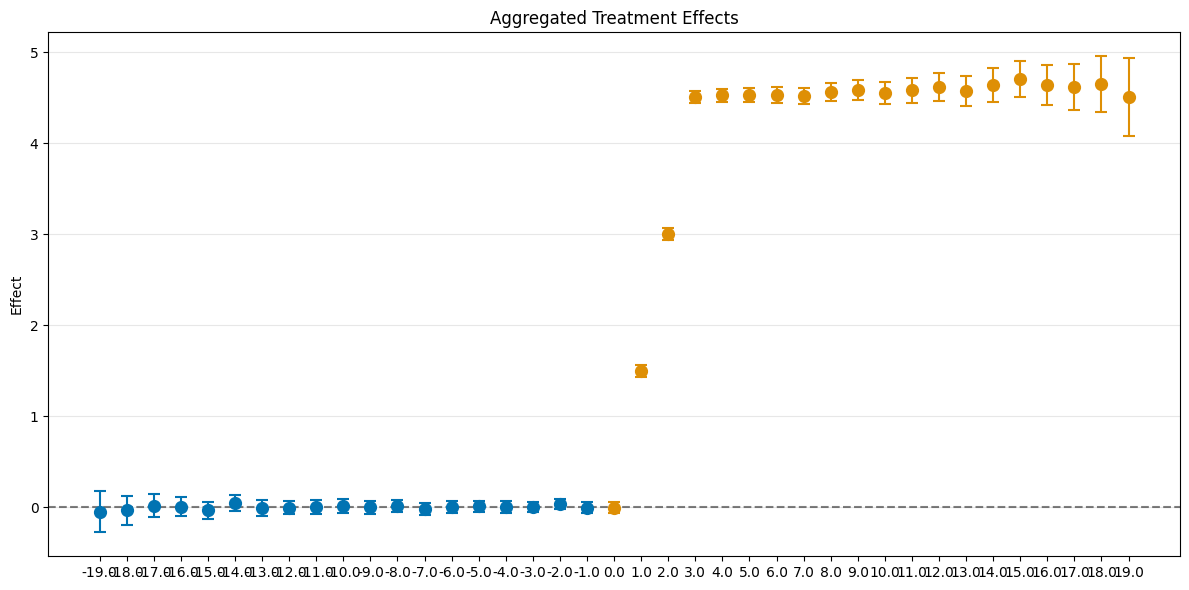

In [192]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
aggregated_eventstudy2 = dml_obj_linear_logistic.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy2.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy2)
fig, ax = aggregated_eventstudy2.plot_effects()

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

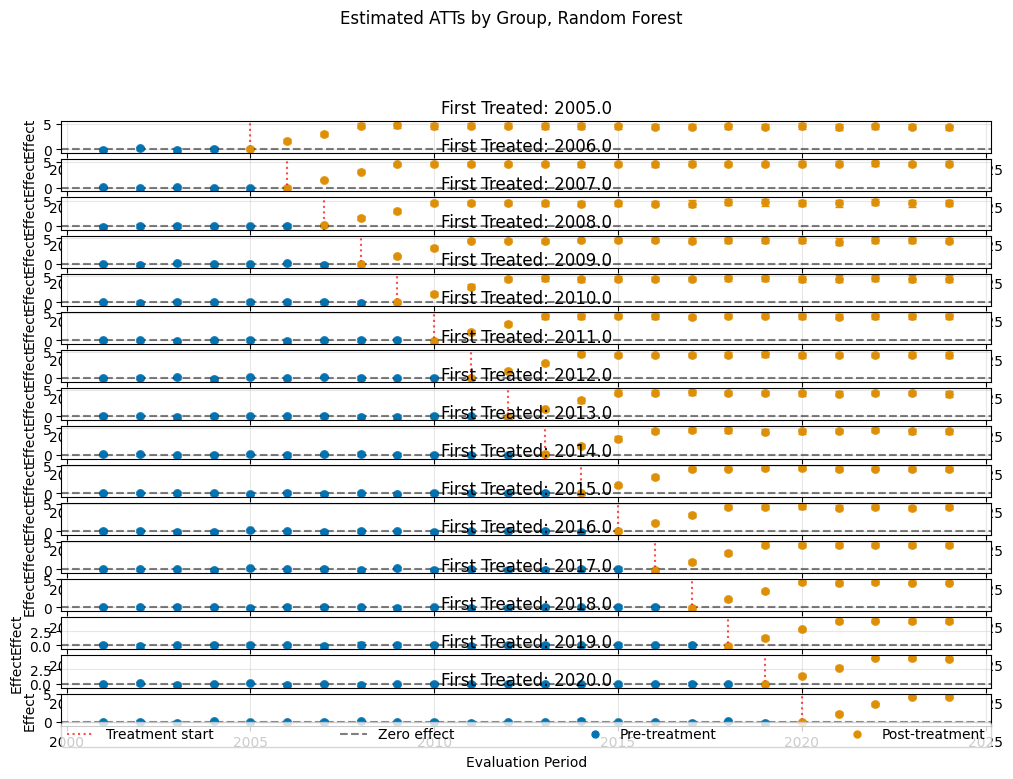

In [193]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

dml_obj_rf = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    ml_m=RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    control_group="never_treated",
    n_folds=10
)

dml_obj_rf.fit()
dml_obj_rf.bootstrap(n_rep_boot=5000)
dml_obj_rf.plot_effects(title="Estimated ATTs by Group, Random Forest")


================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.023298 0.032004 125.711773    0.0 3.960571 4.086025
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.043386  0.072115   -0.601625  0.547424 -0.184730  0.097957
-18.0  0.006150  0.052338    0.117500  0.906464 -0.096431  0.108730
-17.0  0.015438  0.039853    0.387362  0.698488 -0.062673  0.093548
-16.0 -0.004310  0.034468   -0.125032  0.900498 -0.071866  0.063247
-15.0 -0.018220  0.029787   -0.611661  0.540762 -0.076602  0.040162
-14.0  0.043254  0.029123    1.485229  0.137483 -0.013826  0.100334
-13.0 -0.001904  0.027545   -0.069106  0.944905 -0.055891  0.052084
-12.0 -0.008045  0.023132   -0.347797  0.727992 -0.053384  0.037293
-11.0  0.003952  0.024370    0.162186  0.871159 -0.0438

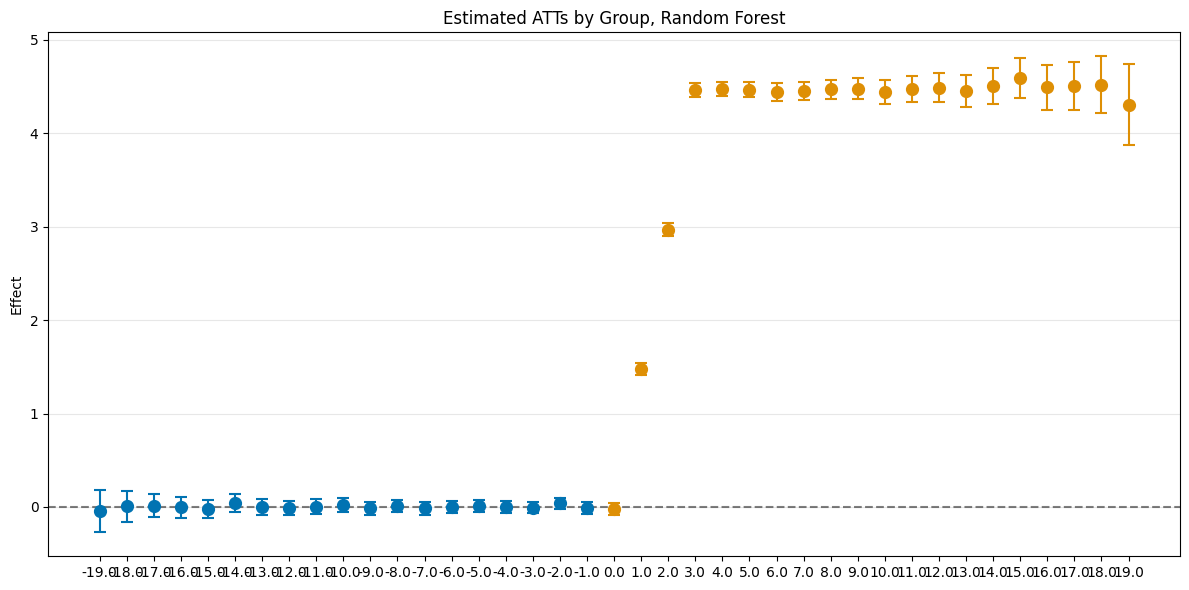

In [194]:
# 1. Agregar os efeitos como estudo de eventos (event time = t - g)
es_rf = dml_obj_rf.aggregate("eventstudy")

# 2. Rodar o bootstrap para os efeitos agregados
es_rf.aggregated_frameworks.bootstrap()

# 3. Plotar os efeitos agregados
es_rf.plot_effects(title="Estimated ATTs by Group, Random Forest")

# 4. Tabela de resultados
print(es_rf)

In [ ]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_rf.bootstrap(n_rep_boot=5000)
aggregated_eventstudy3 = dml_obj_rf.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy3.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy3)
fig, ax = aggregated_eventstudy3.plot_effects()

### Spatially-Disentangled Doubly Robust Machine Learning for Policy Evaluation

Separando a base de dados em duas partes, uma para cada estimativa.

In [149]:
panel_de

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
25,1718451,Pugmil,TO,-0.138264,-0.979926,0.342451,-10.422515,-48.882359,2000,NaN,...,9.966838,0.0,0,NaN,NaN,0,0,1,NaN,NaN
26,1718451,Pugmil,TO,-0.132444,-0.961857,0.357684,-10.422515,-48.882359,2001,NaN,...,9.612030,0.0,0,NaN,NaN,0,0,1,NaN,NaN
27,1718451,Pugmil,TO,-0.126624,-0.943788,0.372916,-10.422515,-48.882359,2002,NaN,...,10.093803,0.0,0,NaN,NaN,0,0,1,NaN,NaN
28,1718451,Pugmil,TO,-0.120803,-0.925718,0.388149,-10.422515,-48.882359,2003,NaN,...,9.824669,0.0,0,NaN,NaN,0,0,1,NaN,NaN
29,1718451,Pugmil,TO,-0.114983,-0.907649,0.403381,-10.422515,-48.882359,2004,NaN,...,9.941119,0.0,0,NaN,NaN,0,0,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


In [150]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,NaN,...,28.078476,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,NaN,...,27.913217,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,NaN,...,28.174238,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,NaN,...,28.462075,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,NaN,...,27.960155,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


#### Direct Effect Estimation

In [ ]:
panel_de.loc[panel_de['g_treated'] == 0, 'g_treated'] = np.inf
panel_de['g_treated'] = panel_de['g_treated'].astype(float)
panel_de['year'] = panel_de['year'].astype(int)
panel_de['g_treated'] = panel_de['g_treated'].fillna(np.inf)
panel_de = panel_de.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [ ]:
# Direct Effect (DE) Data
dml_data_DE = DoubleMLPanelData(
    data=panel_de,
    y_col="Y",
    d_cols="g_treated",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['g_treated']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 3298

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82450 entries, 0 to 82449
Columns: 28 entries, codmun to g_neighbor
dtypes: float64(19), int64(6), object(3)
memory usage: 17.6+ MB



In [ ]:
dml_obj_DE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_DE,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_DE.fit()

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001) -0.0716   0.0735  -0.9750  0.3296 -0.2156  0.0724
ATT(2005.0,2001,2002)  0.1567   0.0789   1.9869  0.0469  0.0021  0.3113
ATT(2005.0,2002,2003) -0.1793   0.0758  -2.3662  0.0180 -0.3278 -0.0308
ATT(2005.0,2003,2004)  0.0634   0.0871   0.7274  0.4670 -0.1074  0.2341
ATT(2005.0,2004,2005)  0.1765   0.0690   2.5587  0.0105  0.0413  0.3118
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.0292   0.0633   0.4608  0.6449 -0.0950  0.1533
ATT(2020.0,2019,2021)  1.5565   0.0635  24.5209  0.0000  1.4321  1.6809
ATT(2020.0,2019,2022)  3.1367   0.0607  51.7103  0.0000  3.0178  3.2556
ATT(2020.0,2019,2023)  4.4861   0.0495  90.6909  0.0000  4.3892  4.5831
ATT(2020.0,2019,2024)  4.6223   0.0641  72.1497  0.0000  4.4967  4.7478

[384 rows x 6 columns]


In [ ]:
level = 0.95
ci = dml_obj_DE.confint(level=level)
dml_obj_DE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_DE.confint(level=level, joint=True)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.349530  0.206288
ATT(2005.0,2001,2002) -0.141662  0.455059
ATT(2005.0,2002,2003) -0.465942  0.107359
ATT(2005.0,2003,2004) -0.266165  0.392875
ATT(2005.0,2004,2005) -0.084478  0.437562
...                         ...       ...
ATT(2020.0,2019,2020) -0.210431  0.268806
ATT(2020.0,2019,2021)  1.316364  1.796640
ATT(2020.0,2019,2022)  2.907195  3.366149
ATT(2020.0,2019,2023)  4.298996  4.673267
ATT(2020.0,2019,2024)  4.379906  4.864635

[384 rows x 2 columns]


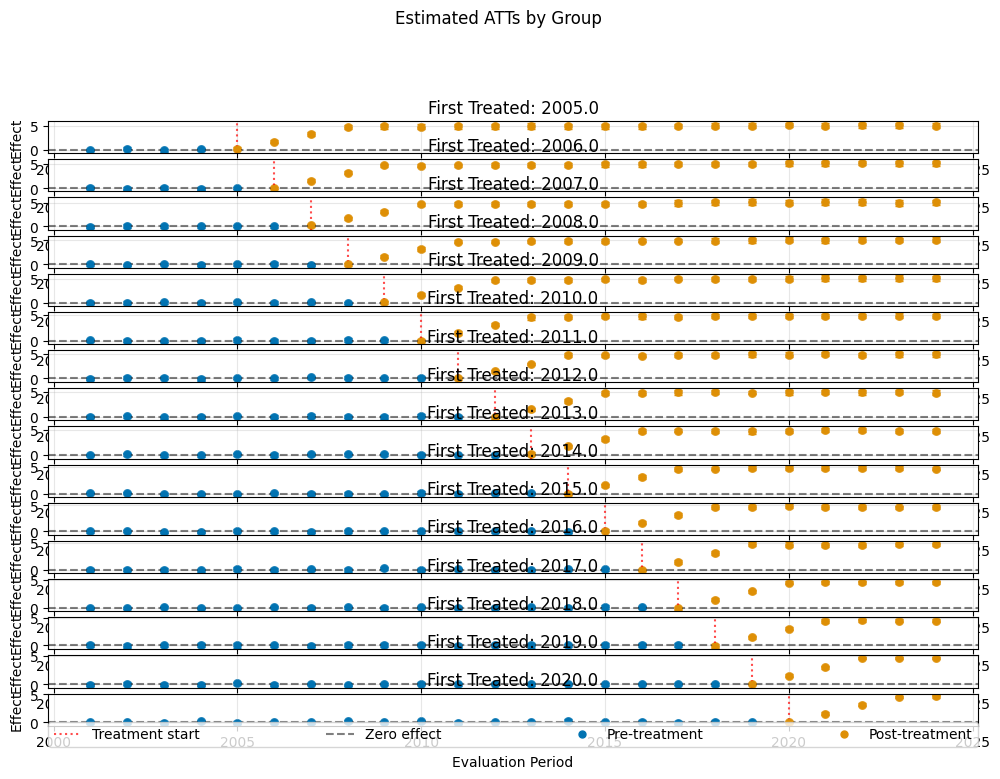

In [155]:
fig, ax = dml_obj_DE.plot_effects()

In [ ]:
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
print(aggregated_eventstudy_DE)

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
   coef  std err          t  P>|t|    2.5 %   97.5 %
4.38241 0.031381 139.650785    0.0 4.320904 4.443916
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.049431  0.070838   -0.697809  0.485297 -0.188271  0.089408
-18.0 -0.029888  0.050363   -0.593460  0.552874 -0.128597  0.068821
-17.0  0.014471  0.039456    0.366767  0.713792 -0.062860  0.091802
-16.0  0.002802  0.032920    0.085119  0.932167 -0.061719  0.067323
-15.0 -0.030867  0.028123   -1.097573  0.272391 -0.085987  0.024253
-14.0  0.058192  0.028572    2.036683  0.041682  0.002192  0.114192
-13.0  0.005741  0.026898    0.213429  0.830992 -0.046978  0.058460
-12.0  0.009373  0.022436    0.417756  0.676126 -0.034601  0.053347
-11.0  0.015395  0.023807    0.646656  0.517855 -0.031266

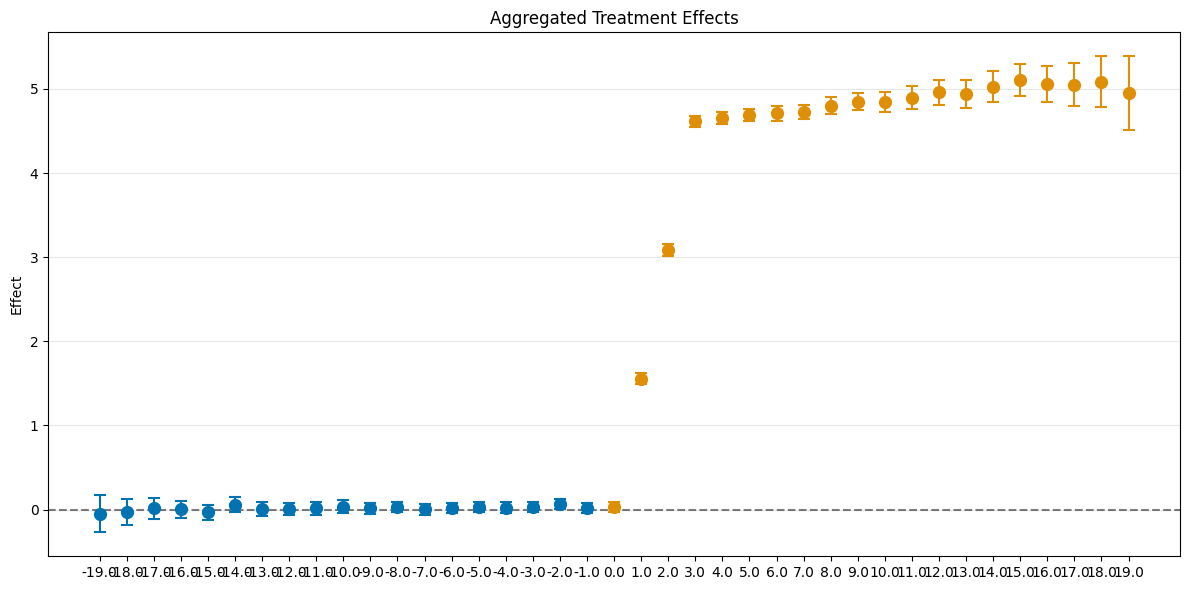

In [156]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_DE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_DE = dml_obj_DE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_DE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_DE)
fig, ax = aggregated_eventstudy_DE.plot_effects()

#### Efeito do Tratamento Indireto

In [157]:
panel_id

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,Y,WD,is_neighbor_of_treated,g_neighbor_of_treated_a,g_neighbor_of_treated,treated,neighbor_of_treated,never_treated,g_treated,g_neighbor
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,NaN,...,28.078476,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,NaN,...,27.913217,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,NaN,...,28.174238,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,NaN,...,28.462075,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,NaN,...,27.960155,0.0,1,NaN,2014.0,0,1,0,NaN,2014.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,NaN,...,9.700622,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,NaN,...,9.979858,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,NaN,...,9.483178,0.0,0,NaN,NaN,0,0,1,NaN,NaN
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,NaN,...,9.280707,0.0,0,NaN,NaN,0,0,1,NaN,NaN


In [158]:
panel_id.loc[panel_id['g_neighbor'] == 0, 'g_neighbor'] = np.inf

panel_id['g_neighbor'] = panel_id['g_neighbor'].astype(float)
panel_id['year'] = panel_id['year'].astype(int)

panel_id['g_neighbor'] = panel_id['g_neighbor'].fillna(np.inf)

panel_id = panel_id.sort_values(by=['codmun', 'year']).reset_index(drop=True)

In [159]:
# Indirect Effect (IE) Data
dml_data_IE = DoubleMLPanelData(
    data=panel_id,
    y_col="Y",
    d_cols="g_neighbor",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)

In [160]:
dml_obj_IE = DoubleMLDIDMulti(
    obj_dml_data=dml_data_IE,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_IE.fit()
print(dml_obj_IE.summary.round(4))

                         coef  std err        t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.0118   0.0371   0.3165  0.7516 -0.0610  0.0846
ATT(2005.0,2001,2002)  0.0163   0.0375   0.4340  0.6643 -0.0572  0.0897
ATT(2005.0,2002,2003) -0.0404   0.0409  -0.9883  0.3230 -0.1206  0.0397
ATT(2005.0,2003,2004)  0.0165   0.0390   0.4243  0.6713 -0.0598  0.0929
ATT(2005.0,2004,2005)  0.6001   0.0360  16.6492  0.0000  0.5295  0.6707
...                       ...      ...      ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.5805   0.0413  14.0624  0.0000  0.4996  0.6614
ATT(2020.0,2019,2021)  0.6141   0.0411  14.9376  0.0000  0.5335  0.6947
ATT(2020.0,2019,2022)  0.5774   0.0413  13.9781  0.0000  0.4964  0.6583
ATT(2020.0,2019,2023)  0.6335   0.0409  15.4735  0.0000  0.5533  0.7138
ATT(2020.0,2019,2024)  0.5889   0.0374  15.7350  0.0000  0.5156  0.6623

[384 rows x 6 columns]


In [161]:
level = 0.95

ci = dml_obj_IE.confint(level=level)
dml_obj_IE.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj_IE.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.128414  0.151930
ATT(2005.0,2001,2002) -0.125193  0.157730
ATT(2005.0,2002,2003) -0.194787  0.113936
ATT(2005.0,2003,2004) -0.130481  0.163543
ATT(2005.0,2004,2005)  0.464077  0.736113
...                         ...       ...
ATT(2020.0,2019,2020)  0.424736  0.736309
ATT(2020.0,2019,2021)  0.458955  0.769234
ATT(2020.0,2019,2022)  0.421497  0.733247
ATT(2020.0,2019,2023)  0.479028  0.788043
ATT(2020.0,2019,2024)  0.447680  0.730162

[384 rows x 2 columns]


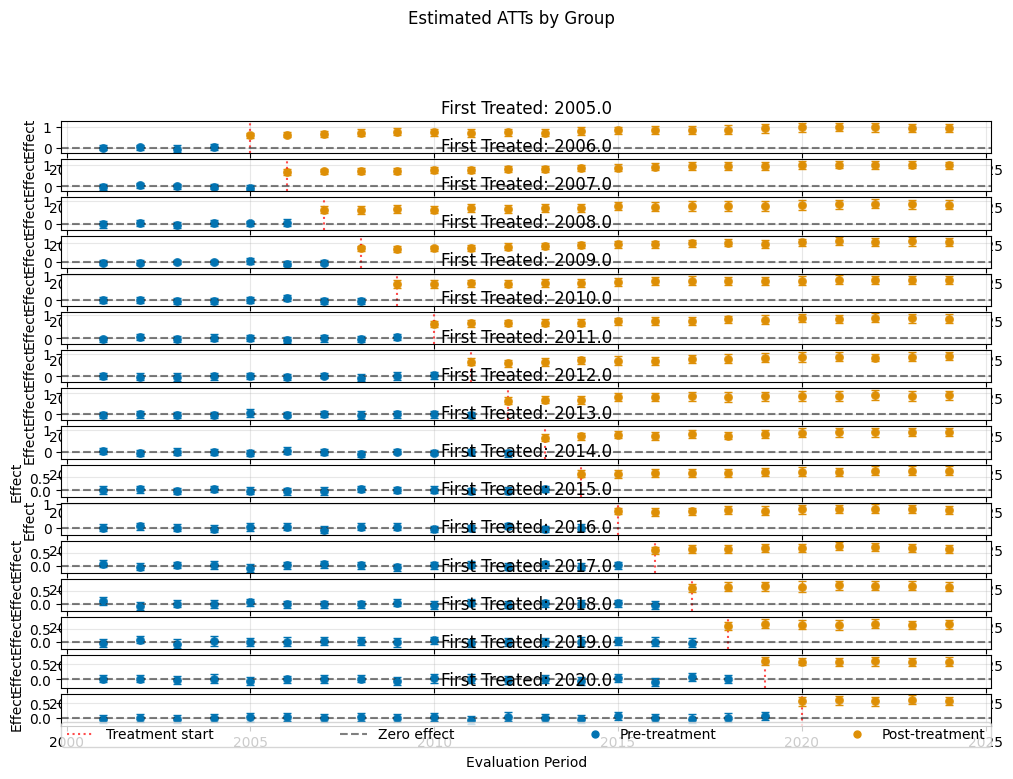

In [163]:
fig, ax = dml_obj_IE.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err        t  P>|t|    2.5 %   97.5 %
0.822553 0.012696 64.78662    0.0 0.797668 0.847437
------------------ Aggregated Effects         ------------------
           coef   std err          t     P>|t|     2.5 %    97.5 %
-19.0 -0.037505  0.038192  -0.982014  0.326093 -0.112359  0.037349
-18.0  0.004561  0.023863   0.191116  0.848434 -0.042210  0.051331
-17.0 -0.009720  0.021115  -0.460329  0.645280 -0.051104  0.031665
-16.0  0.025874  0.018952   1.365270  0.172168 -0.011271  0.063019
-15.0 -0.003821  0.016912  -0.225931  0.821255 -0.036968  0.029326
-14.0 -0.010855  0.015235  -0.712467  0.476176 -0.040715  0.019006
-13.0  0.005737  0.014188   0.404352  0.685954 -0.022071  0.033545
-12.0  0.025995  0.012745   2.039634  0.041387  0.001015  0.050974
-11.0 -0.022812  0.011936  -1.911285  0.055968 -0.046205  0.000581
-

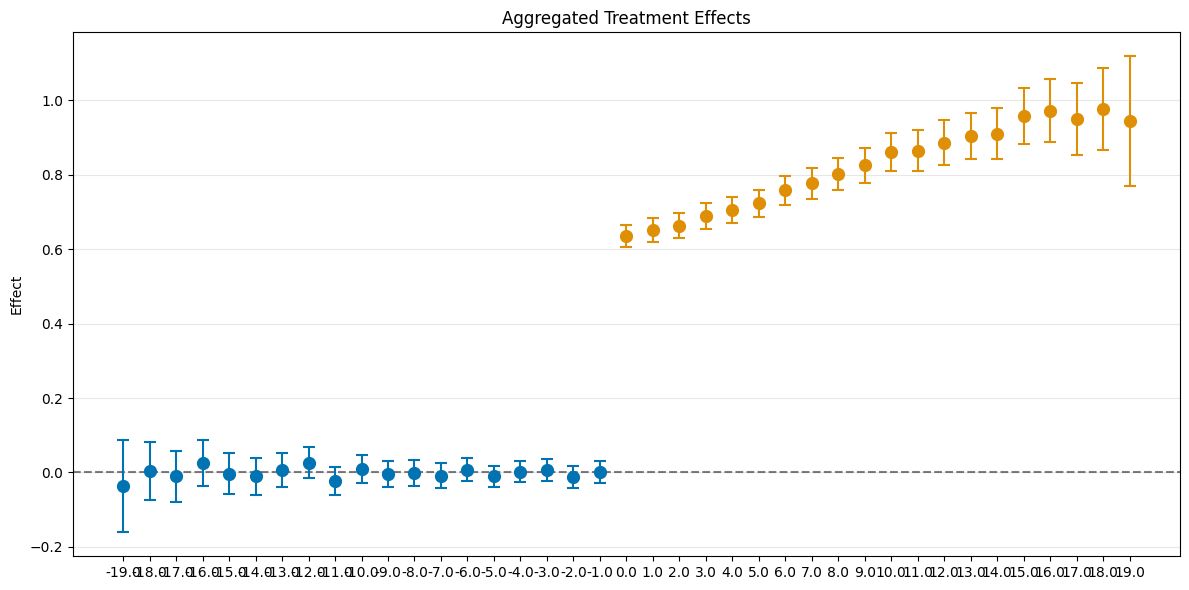

In [164]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj_IE.bootstrap(n_rep_boot=5000)
aggregated_eventstudy_IE = dml_obj_IE.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy_IE.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy_IE)
fig, ax = aggregated_eventstudy_IE.plot_effects()